<a href="https://colab.research.google.com/github/Salma19mostafa/Salma19mostafa/blob/main/My12th_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Colab-ready: install any missing packages (uncomment if needed)
# !pip install seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix, accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

sns.set(style="whitegrid")
%matplotlib inline


In [2]:
df = pd.read_csv('/content/AI_Impact_on_Jobs_2030.csv')
display(df.head())

,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,High,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,Low,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,High,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83
3,Software Engineer,136530,13,PhD,0.39,0.68,0.60,Medium,0.43,0.21,0.57,0.03,0.84,0.45,0.40,0.93,0.73,0.33
4,Financial Analyst,70397,22,High School,0.52,1.46,0.64,Medium,0.75,0.54,0.59,0.97,0.61,0.28,0.30,0.17,0.02,0.42


In [3]:
print(df.info())
display(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Job_Title                    3000 non-null   object 
 1   Average_Salary               3000 non-null   int64  
 2   Years_Experience             3000 non-null   int64  
 3   Education_Level              3000 non-null   object 
 4   AI_Exposure_Index            3000 non-null   float64
 5   Tech_Growth_Factor           3000 non-null   float64
 6   Automation_Probability_2030  3000 non-null   float64
 7   Risk_Category                3000 non-null   object 
 8   Skill_1                      3000 non-null   float64
 9   Skill_2                      3000 non-null   float64
 10  Skill_3                      3000 non-null   float64
 11  Skill_4                      3000 non-null   float64
 12  Skill_5                      3000 non-null   float64
 13  Skill_6           

,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
count,3000,3000.000000,3000.000000,3000,3000.000000,3000.000000,3000.000000,3000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
unique,20,NaN,NaN,4,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Software Engineer,NaN,NaN,High School,NaN,NaN,NaN,Medium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,175,NaN,NaN,784,NaN,NaN,NaN,1521,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,89372.279000,14.677667,NaN,0.501283,0.995343,0.501503,NaN,0.496973,0.497233,0.499313,0.503667,0.490270,0.499807,0.499160,0.502843,0.501433,0.493627
std,NaN,34608.088767,8.739788,NaN,0.284004,0.287669,0.247881,NaN,0.287888,0.288085,0.288354,0.287063,0.285818,0.286050,0.288044,0.289832,0.285818,0.286464
min,NaN,30030.000000,0.000000,NaN,0.000000,0.500000,0.050000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,58640.000000,7.000000,NaN,0.260000,0.740000,0.310000,NaN,0.240000,0.250000,0.250000,0.260000,0.240000,0.260000,0.250000,0.250000,0.260000,0.250000
50%,NaN,89318.000000,15.000000,NaN,0.500000,1.000000,0.500000,NaN,0.505000,0.500000,0.500000,0.510000,0.490000,0.500000,0.490000,0.500000,0.500000,0.490000
75%,NaN,119086.500000,22.000000,NaN,0.740000,1.240000,0.700000,NaN,0.740000,0.740000,0.750000,0.750000,0.730000,0.740000,0.750000,0.750000,0.740000,0.740000


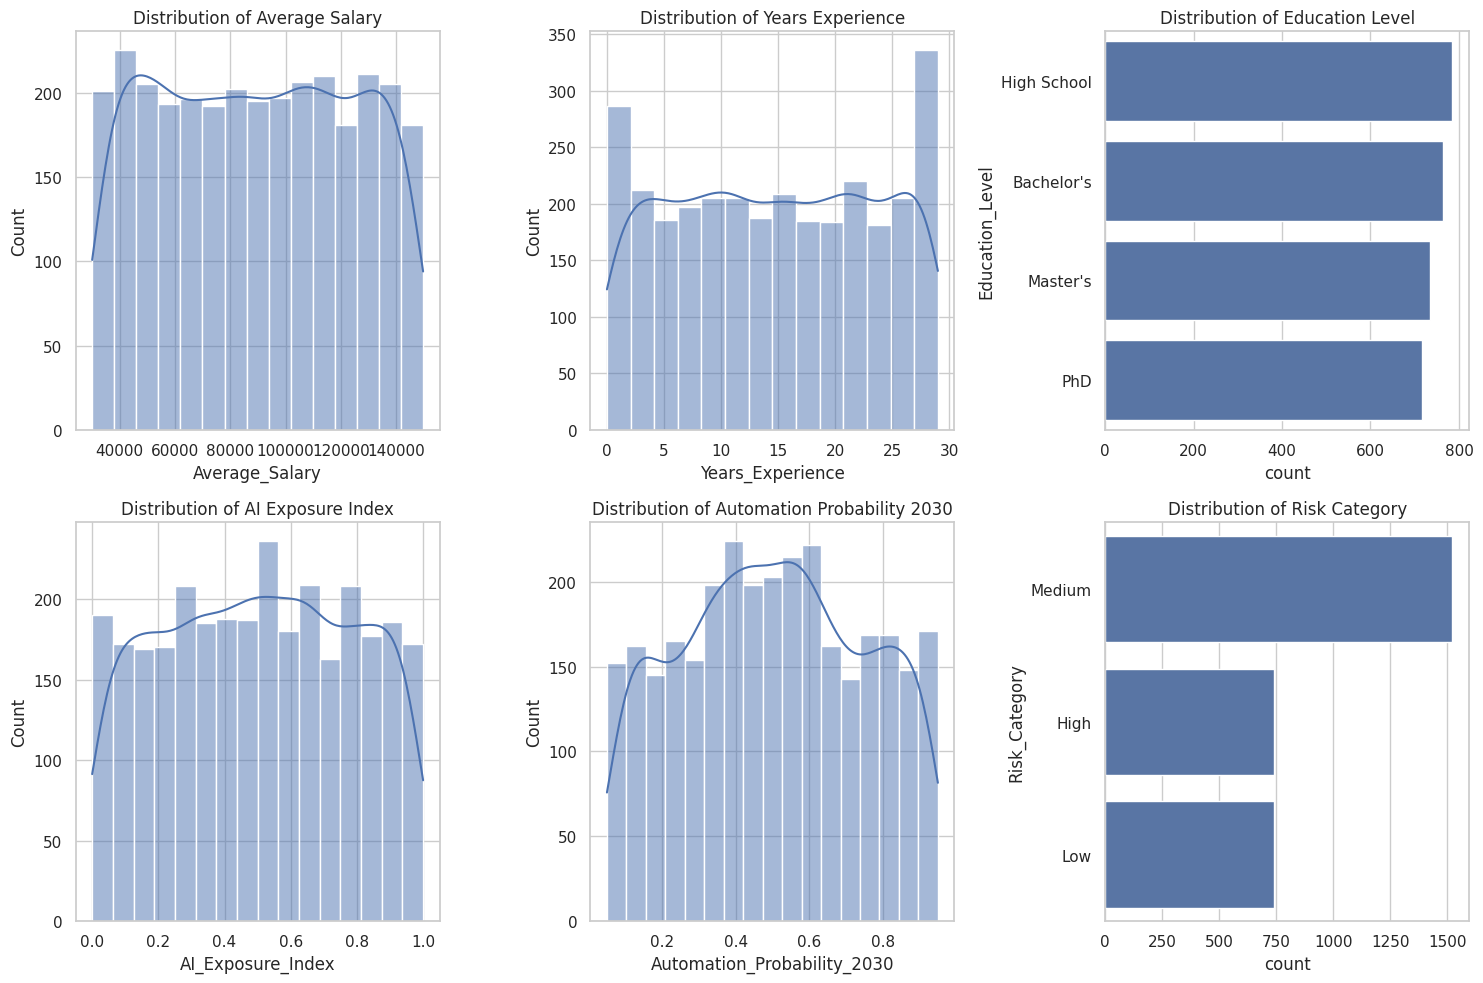

In [4]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.histplot(df['Average_Salary'], kde=True)
plt.title('Distribution of Average Salary')

plt.subplot(2, 3, 2)
sns.histplot(df['Years_Experience'], kde=True)
plt.title('Distribution of Years Experience')

plt.subplot(2, 3, 3)
sns.countplot(data=df, y='Education_Level', order=df['Education_Level'].value_counts().index)
plt.title('Distribution of Education Level')

plt.subplot(2, 3, 4)
sns.histplot(df['AI_Exposure_Index'], kde=True)
plt.title('Distribution of AI Exposure Index')

plt.subplot(2, 3, 5)
sns.histplot(df['Automation_Probability_2030'], kde=True)
plt.title('Distribution of Automation Probability 2030')

plt.subplot(2, 3, 6)
sns.countplot(data=df, y='Risk_Category', order=df['Risk_Category'].value_counts().index)
plt.title('Distribution of Risk Category')

plt.tight_layout()
plt.show()

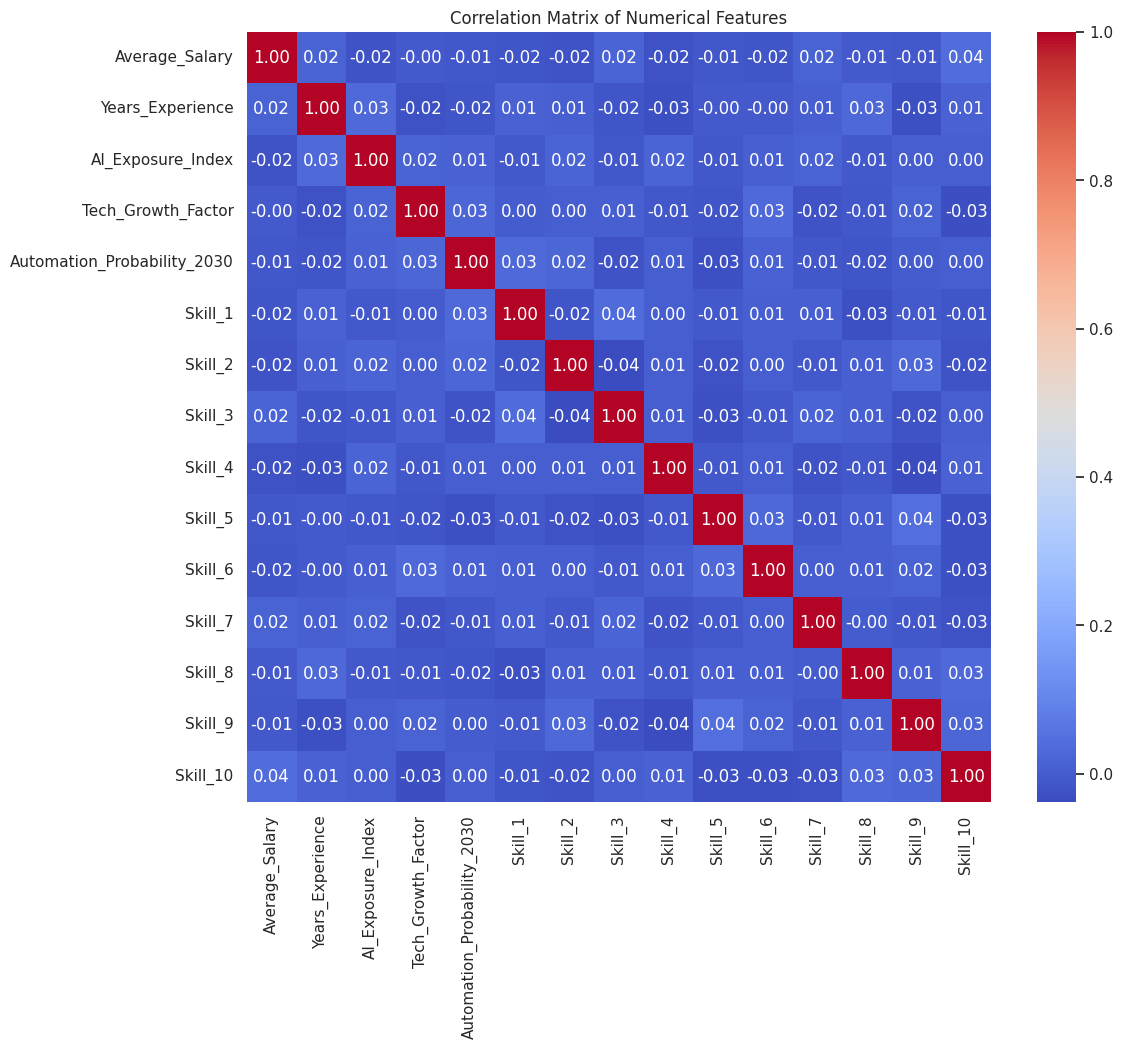

In [5]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

/tmp/ipykernel_13107/1675892714.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.sort_values(by='Automation_Probability_2030', ascending=False), x='Automation_Probability_2030', y='Job_Title', palette='viridis')


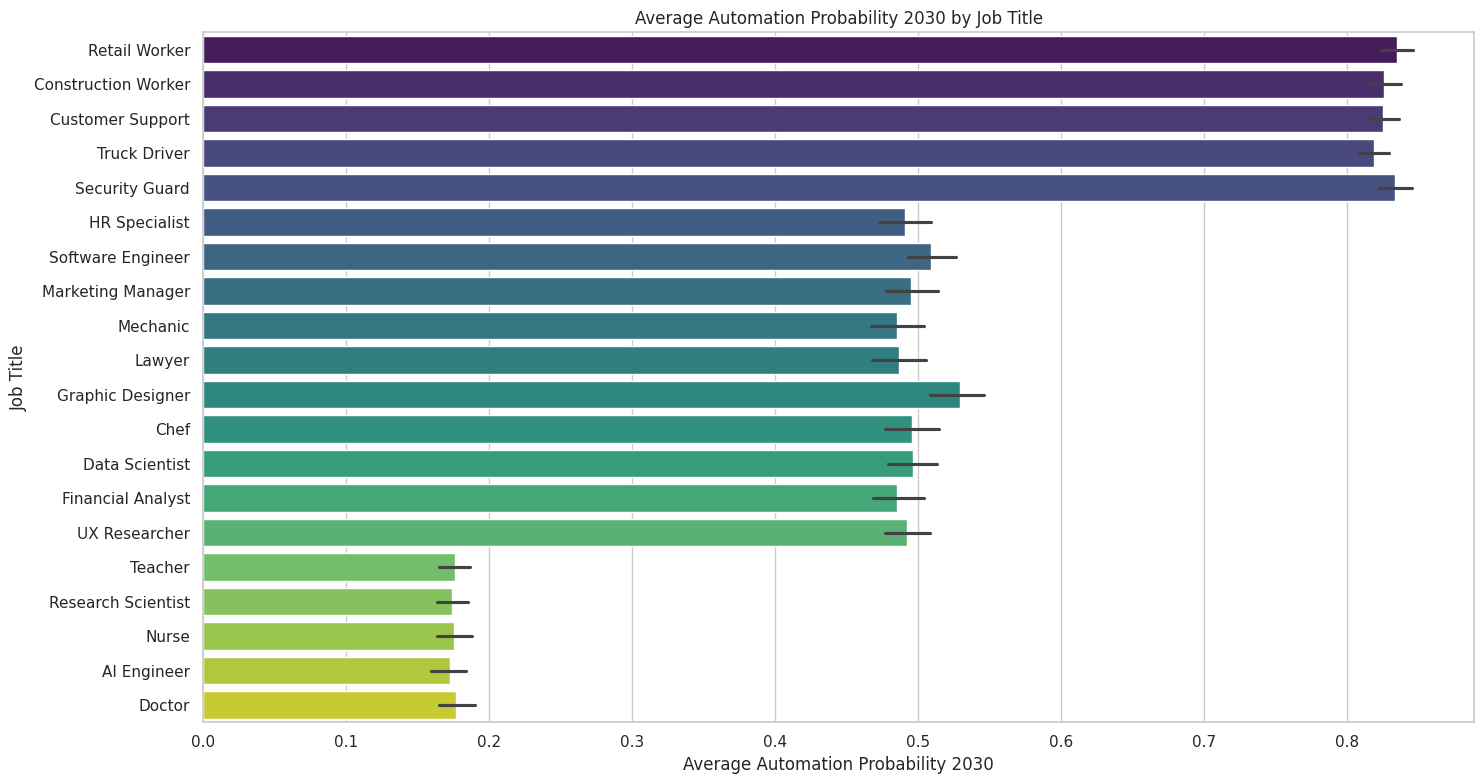

In [6]:
plt.figure(figsize=(15, 8))
sns.barplot(data=df.sort_values(by='Automation_Probability_2030', ascending=False), x='Automation_Probability_2030', y='Job_Title', palette='viridis')
plt.title('Average Automation Probability 2030 by Job Title')
plt.xlabel('Average Automation Probability 2030')
plt.ylabel('Job Title')
plt.tight_layout()
plt.show()

/tmp/ipykernel_13107/2279055265.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.sort_values(by='Automation_Probability_2030', ascending=False), x='Education_Level', y='Automation_Probability_2030', palette='viridis')


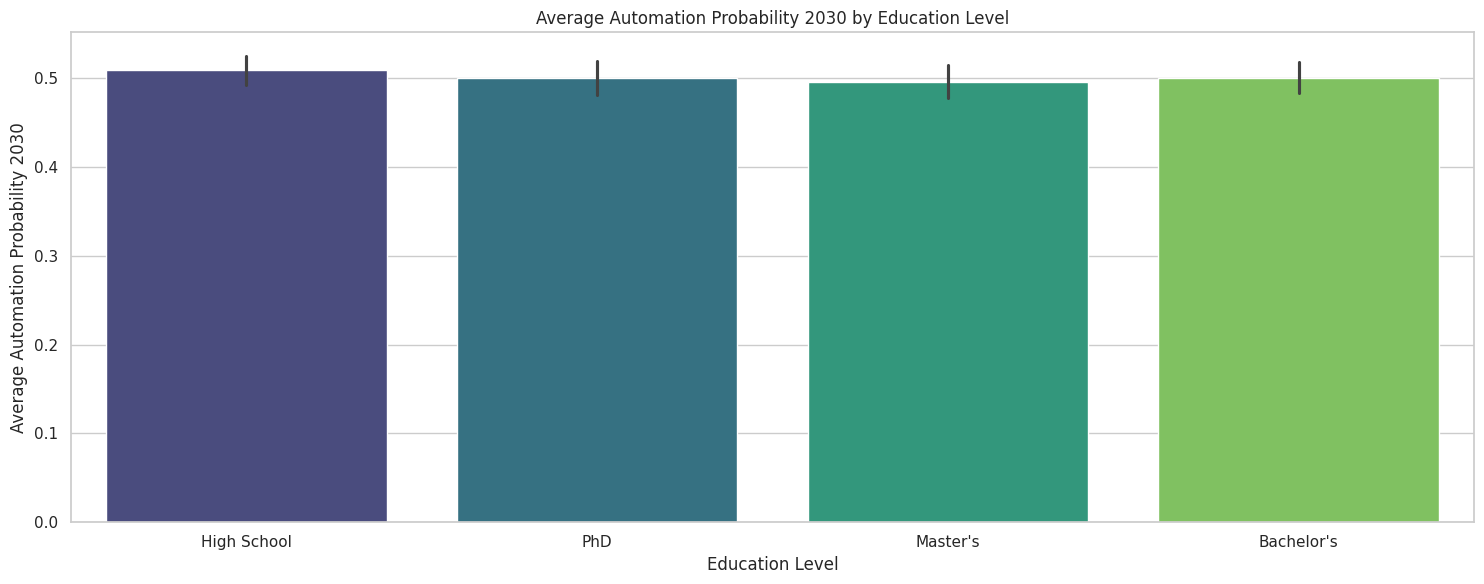

In [7]:
plt.figure(figsize=(15, 6))
sns.barplot(data=df.sort_values(by='Automation_Probability_2030', ascending=False), x='Education_Level', y='Automation_Probability_2030', palette='viridis')
plt.title('Average Automation Probability 2030 by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Average Automation Probability 2030')
plt.tight_layout()
plt.show()

/tmp/ipykernel_13107/1508656210.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.sort_values(by='Automation_Probability_2030', ascending=False), x='Risk_Category', y='Automation_Probability_2030', palette='viridis')


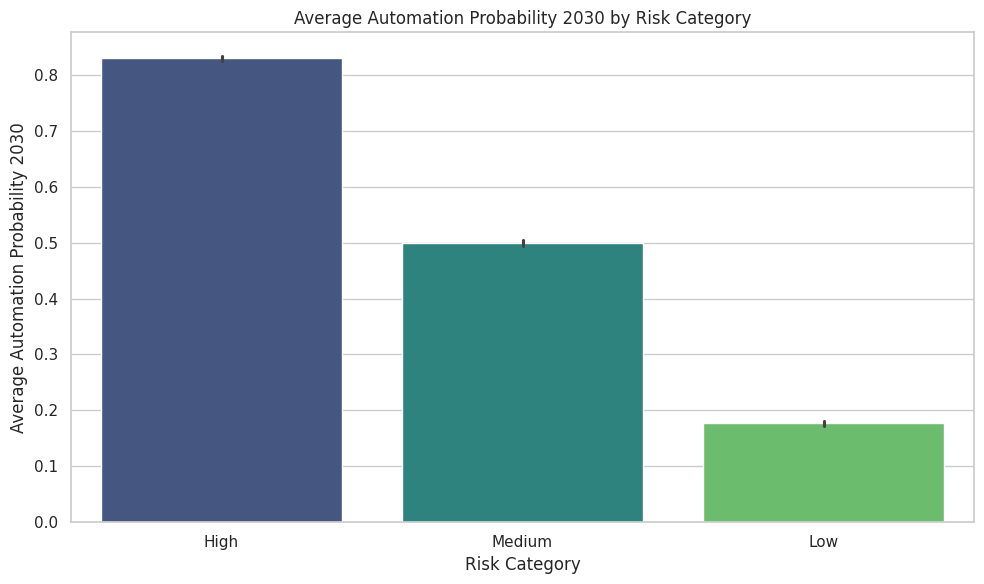

In [8]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df.sort_values(by='Automation_Probability_2030', ascending=False), x='Risk_Category', y='Automation_Probability_2030', palette='viridis')
plt.title('Average Automation Probability 2030 by Risk Category')
plt.xlabel('Risk Category')
plt.ylabel('Average Automation Probability 2030')
plt.tight_layout()
plt.show()

In [9]:
# Define features (X) and target (y)
X = df.drop('Automation_Probability_2030', axis=1)
y = df['Automation_Probability_2030']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2400, 17)
X_test shape: (600, 17)
y_train shape: (2400,)
y_test shape: (600,)


In [10]:
# Identify categorical and numerical features
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

# Remove 'Job_Title' from categorical features as it has too many unique values and can be handled differently or dropped if needed later.
categorical_features.remove('Job_Title') # Removing Job_Title as it has high cardinality and might not be suitable for one-hot encoding directly.

print(f"Numerical features: {numerical_features}")
print(f"Categorical features: {categorical_features}")

# Preprocessing for numerical features (scaling)
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Preprocessing for categorical features (one-hot encoding)
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

Numerical features: ['Average_Salary', 'Years_Experience', 'AI_Exposure_Index', 'Tech_Growth_Factor', 'Skill_1', 'Skill_2', 'Skill_3', 'Skill_4', 'Skill_5', 'Skill_6', 'Skill_7', 'Skill_8', 'Skill_9', 'Skill_10']
Categorical features: ['Education_Level', 'Risk_Category']


In [11]:
# Create the full pipeline with preprocessing and a RandomForestRegressor model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Train the model
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [12]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared: {r2:.4f}")

Mean Squared Error: 0.0087
R-squared: 0.8633


Top 10 Feature Importances:
                 Feature  Importance
18    Risk_Category_High    0.398495
19     Risk_Category_Low    0.351310
20  Risk_Category_Medium    0.102760
2      AI_Exposure_Index    0.011531
5                Skill_2    0.011062
9                Skill_6    0.010923
0         Average_Salary    0.010875
7                Skill_4    0.010584
4                Skill_1    0.010436
11               Skill_8    0.010330


/tmp/ipykernel_13107/3113035.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='magma')


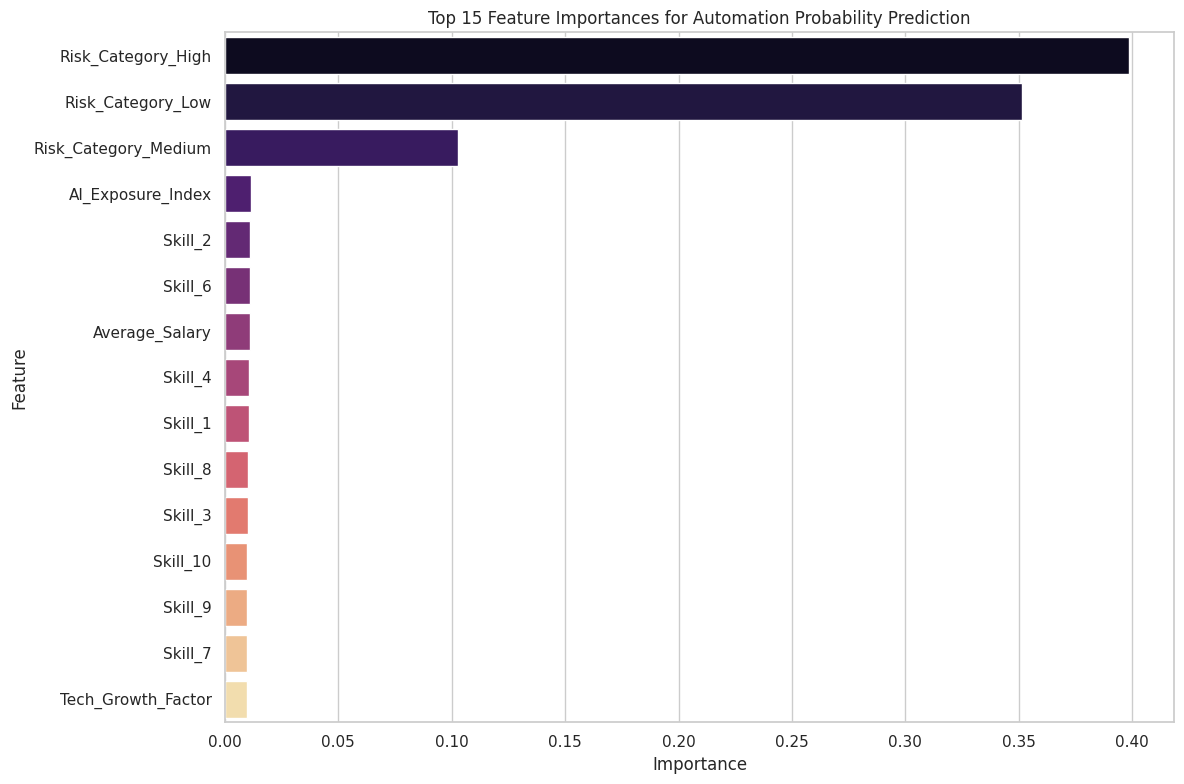

In [14]:
# Get feature importances from the RandomForestRegressor
feature_importances = model.named_steps['regressor'].feature_importances_

# Get feature names from the preprocessor
# For numerical features, direct names are available
# For categorical features, one-hot encoded names need to be extracted

# Get numerical feature names
numeric_feature_names = X_train[numerical_features].columns.tolist()

# Get one-hot encoded feature names for categorical features
# Need to fit the preprocessor first to get the transformed column names
preprocessor.fit(X_train)
cat_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)

# Combine all feature names
all_feature_names = numeric_feature_names + list(cat_feature_names)

# Create a DataFrame for feature importances
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Display the top 10 most important features
print("Top 10 Feature Importances:")
print(importance_df.head(10))

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='magma')
plt.title('Top 15 Feature Importances for Automation Probability Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

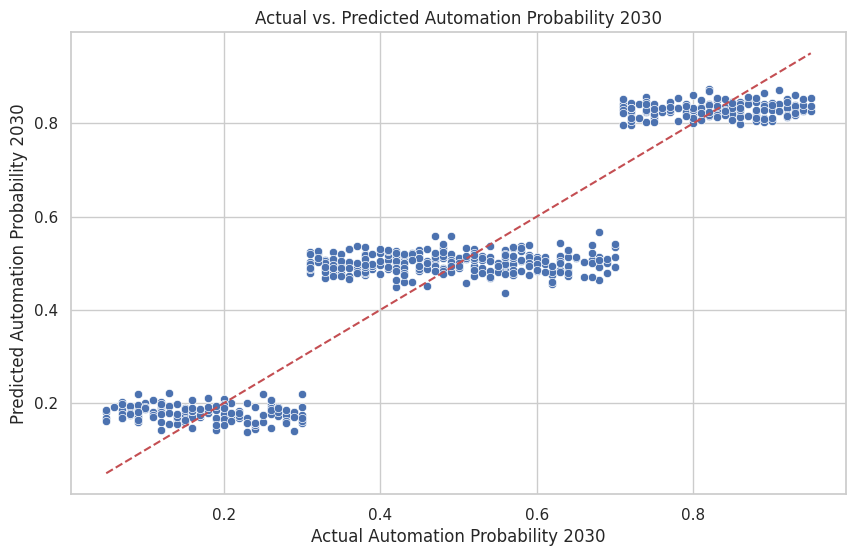

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Automation Probability 2030')
plt.ylabel('Predicted Automation Probability 2030')
plt.title('Actual vs. Predicted Automation Probability 2030')
plt.show()

In [16]:
# Upload the file to Colab or ensure it's in the working directory
file_path = "AI_Impact_on_Jobs_2030.csv"
data = pd.read_csv(file_path)
print("Loaded rows:", len(data))
data.head()


Loaded rows: 3000


,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,High,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,Low,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,High,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83
3,Software Engineer,136530,13,PhD,0.39,0.68,0.60,Medium,0.43,0.21,0.57,0.03,0.84,0.45,0.40,0.93,0.73,0.33
4,Financial Analyst,70397,22,High School,0.52,1.46,0.64,Medium,0.75,0.54,0.59,0.97,0.61,0.28,0.30,0.17,0.02,0.42


In [17]:
# Quick overview
display(data.head(10))
data.info()
data.describe(include="all").T

# Missing values
print("Missing values per column:")
print(data.isnull().sum())


,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,High,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,Low,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,High,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83
3,Software Engineer,136530,13,PhD,0.39,0.68,0.60,Medium,0.43,0.21,0.57,0.03,0.84,0.45,0.40,0.93,0.73,0.33
4,Financial Analyst,70397,22,High School,0.52,1.46,0.64,Medium,0.75,0.54,0.59,0.97,0.61,0.28,0.30,0.17,0.02,0.42
5,AI Engineer,92592,11,Master's,0.29,0.51,0.10,Low,0.71,0.79,0.61,0.93,0.65,0.91,0.85,0.45,0.10,0.37
6,Mechanic,107373,23,PhD,0.67,1.09,0.41,Medium,0.56,0.38,0.97,0.85,0.72,0.24,0.26,0.04,0.71,0.11
7,Teacher,53419,12,High School,0.20,1.40,0.17,Low,0.56,0.70,0.14,0.60,0.54,0.20,0.94,0.60,0.69,0.88
8,HR Specialist,139225,12,Master's,0.30,0.61,0.48,Medium,0.22,0.42,0.88,0.32,0.12,0.36,0.91,0.27,0.65,0.00
9,Customer Support,85016,2,High School,0.01,1.01,0.80,High,0.22,0.12,0.34,0.94,0.32,0.52,0.70,0.36,0.97,0.96


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Job_Title                    3000 non-null   object 
 1   Average_Salary               3000 non-null   int64  
 2   Years_Experience             3000 non-null   int64  
 3   Education_Level              3000 non-null   object 
 4   AI_Exposure_Index            3000 non-null   float64
 5   Tech_Growth_Factor           3000 non-null   float64
 6   Automation_Probability_2030  3000 non-null   float64
 7   Risk_Category                3000 non-null   object 
 8   Skill_1                      3000 non-null   float64
 9   Skill_2                      3000 non-null   float64
 10  Skill_3                      3000 non-null   float64
 11  Skill_4                      3000 non-null   float64
 12  Skill_5                      3000 non-null   float64
 13  Skill_6           

In [19]:
# Standardize column names (strip whitespace)
data.columns = [c.strip() for c in data.columns]

# Basic cleaning decisions:
# - If there are obvious duplicates, remove them
data = data.drop_duplicates()

# - If any numeric columns are read as object, coerce
numeric_cols = ["Average_Salary","Years_Experience","AI_Exposure_Index","Tech_Growth_Factor","Automation_Probability_2030"]
for c in numeric_cols:
    if c in data.columns:
        data[c] = pd.to_numeric(data[c], errors="coerce")

# - Handle missing values: simple strategy (median for numeric, mode for categorical)
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

for c in data.select_dtypes(include=["float64","int64"]).columns:
    data[c] = num_imputer.fit_transform(data[[c]])

for c in data.select_dtypes(include=["object","category"]).columns:
    data[c] = cat_imputer.fit_transform(data[[c]]).ravel()


In [20]:
# Average salary by Job_Title and Risk_Category
if "Job_Title" in data.columns:
    top_salary_by_job = data.groupby("Job_Title")["Average_Salary"].mean().sort_values(ascending=False).head(20)
    display(top_salary_by_job)

if "Risk_Category" in data.columns:
    display(data.groupby("Risk_Category")["Average_Salary"].agg(["count","mean","median"]).sort_values("mean", ascending=False))


,Average_Salary
Job_Title,
Graphic Designer,96423.468750
Lawyer,92441.878788
Chef,91407.801418
Teacher,90885.759036
Construction Worker,90800.333333
AI Engineer,90759.828571
Data Scientist,90629.550898
Software Engineer,90264.737143
Mechanic,89807.647059


,count,mean,median
Risk_Category,,,
Medium,1521,90451.414859,91775.0
Low,739,89166.776725,87889.0
High,740,87359.441892,86120.0


In [21]:
# Highest and lowest average salary rows
highest = data.loc[data["Average_Salary"].idxmax()]
lowest = data.loc[data["Average_Salary"].idxmin()]
print("Highest salary row:")
display(highest)
print("Lowest salary row:")
display(lowest)

# Highest automation probability
most_automatable = data.loc[data["Automation_Probability_2030"].idxmax()]
least_automatable = data.loc[data["Automation_Probability_2030"].idxmin()]
print("Most automatable example:")
display(most_automatable)
print("Least automatable example:")
display(least_automatable)


Highest salary row:


,150
Job_Title,Customer Support
Average_Salary,149798.0
Years_Experience,7.0
Education_Level,PhD
AI_Exposure_Index,0.89
Tech_Growth_Factor,1.15
Automation_Probability_2030,0.74
Risk_Category,High
Skill_1,0.44
Skill_2,0.62


Lowest salary row:


,2131
Job_Title,AI Engineer
Average_Salary,30030.0
Years_Experience,0.0
Education_Level,Master's
AI_Exposure_Index,0.44
Tech_Growth_Factor,1.45
Automation_Probability_2030,0.19
Risk_Category,Low
Skill_1,0.33
Skill_2,0.09


Most automatable example:


,87
Job_Title,Retail Worker
Average_Salary,58602.0
Years_Experience,19.0
Education_Level,High School
AI_Exposure_Index,0.4
Tech_Growth_Factor,0.77
Automation_Probability_2030,0.95
Risk_Category,High
Skill_1,0.41
Skill_2,0.89


Least automatable example:


,1
Job_Title,Research Scientist
Average_Salary,133355.0
Years_Experience,20.0
Education_Level,PhD
AI_Exposure_Index,0.62
Tech_Growth_Factor,1.11
Automation_Probability_2030,0.05
Risk_Category,Low
Skill_1,0.02
Skill_2,0.52


/tmp/ipykernel_13107/234347388.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_jobs.values, y=top_jobs.index, palette="viridis")


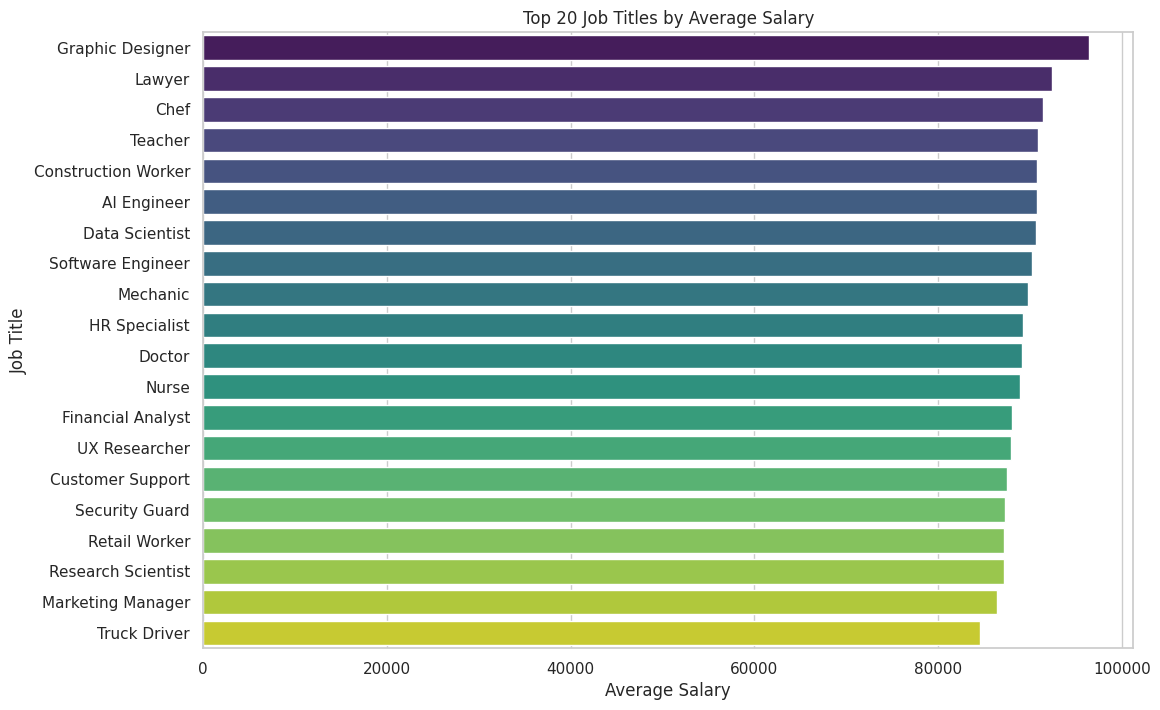

In [22]:
plt.figure(figsize=(12,8))
top_jobs = data.groupby("Job_Title")["Average_Salary"].mean().sort_values(ascending=False).head(20)
sns.barplot(x=top_jobs.values, y=top_jobs.index, palette="viridis")
plt.title("Top 20 Job Titles by Average Salary")
plt.xlabel("Average Salary")
plt.ylabel("Job Title")
plt.show()


In [23]:
# This dataset does not include a Year column; if you have time series, use this pattern:
if "Year" in data.columns:
    plt.figure(figsize=(10,5))
    data.groupby("Year")["Average_Salary"].mean().plot()
    plt.title("Average Salary Over Time")
    plt.ylabel("Average Salary")
    plt.show()
else:
    print("No Year column present; skipping time series step.")


No Year column present; skipping time series step.


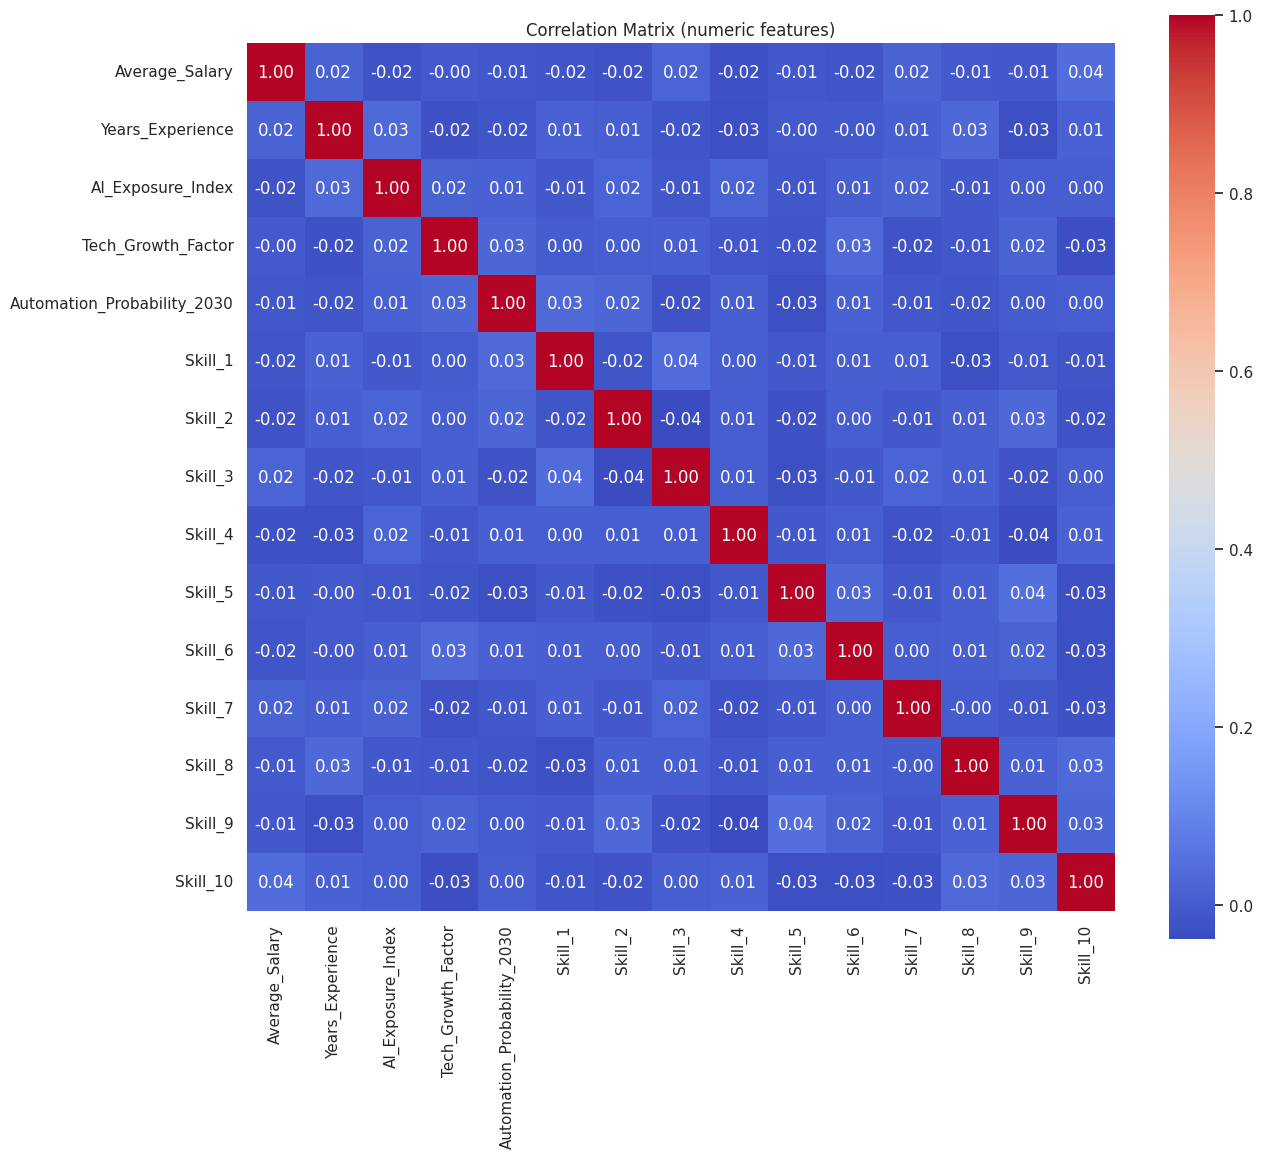

In [24]:
# Correlation among numeric features
num_df = data.select_dtypes(include=["float64","int64"])
plt.figure(figsize=(14,12))
corr = num_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix (numeric features)")
plt.show()


In [25]:
# Salary by Job_Title and Risk_Category
if {"Job_Title","Risk_Category"}.issubset(data.columns):
    pivot = data.pivot_table(index="Job_Title", columns="Risk_Category", values="Average_Salary", aggfunc="mean")
    display(pivot.sort_values(by="High", ascending=False).head(20))


Risk_Category,High,Low,Medium
Job_Title,,,
Construction Worker,90568.111111,NaN,102643.666667
Security Guard,87765.111842,NaN,51215.000000
Customer Support,87487.000000,NaN,NaN
Retail Worker,86318.769737,NaN,132283.666667
Truck Driver,84616.966667,NaN,79668.000000
AI Engineer,NaN,90759.828571,NaN
Chef,NaN,NaN,91407.801418
Data Scientist,NaN,137524.000000,90347.054217
Doctor,NaN,89091.742424,NaN


Some job titles (e.g., high‑skill technical roles) show higher average salaries while many frontline roles show higher automation probability.

Insight: Automation_Probability_2030 varies widely across roles and is not perfectly correlated with salary — some high‑paid roles still face automation risk depending on AI exposure and task structure.

Recommendation: Prioritize upskilling for roles with high automation probability and moderate AI exposure; invest in skills that the dataset marks as high (Skill_# columns) for resilient career paths.

In [27]:
# Prepare features for regression
# Select numeric predictors and engineered skill aggregates
skill_cols = [c for c in data.columns if c.startswith("Skill_")]
base_numeric = ["Average_Salary","Years_Experience","AI_Exposure_Index","Tech_Growth_Factor"]
features = [c for c in base_numeric if c in data.columns] + skill_cols

X = data[features].fillna(0)
y = data["Automation_Probability_2030"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Simple pipeline with scaling and RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
reg = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

print("Regression results:")
print("R2:", r2_score(y_test, y_pred))
# Calculate RMSE by taking the square root of MSE
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("RMSE:", rmse)

# Feature importances
importances = pd.Series(reg.feature_importances_, index=X.columns).sort_values(ascending=False)
display(importances.head(20))


Regression results:
R2: -0.03285652984512133
RMSE: 0.2567825639524615


,0
Average_Salary,0.084997
Skill_1,0.075109
Skill_4,0.075007
Skill_2,0.074941
Tech_Growth_Factor,0.071736
Skill_5,0.071636
Skill_3,0.070728
Skill_9,0.070384
AI_Exposure_Index,0.069957
Skill_6,0.069899


Classification results:
Accuracy: 0.9933333333333333
Classification report:
               precision    recall  f1-score   support

         Low       1.00      0.99      0.99       148
      Medium       0.99      0.99      0.99       304
        High       0.99      1.00      0.99       148

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600



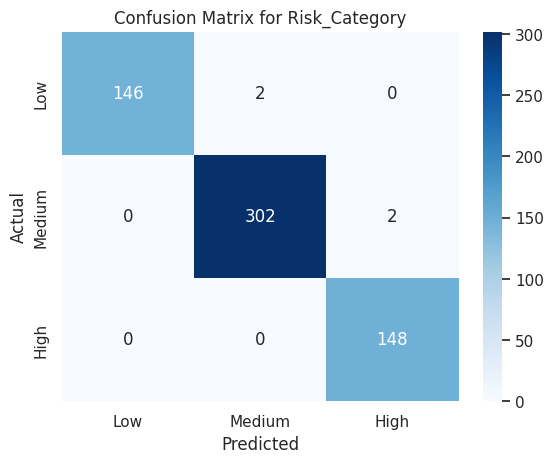

In [29]:
# Encode Risk_Category ordinally (Low < Medium < High)
risk_map = {"Low":0, "Medium":1, "High":2}
data["Risk_Label"] = data["Risk_Category"].map(risk_map)

# Features: numeric + one-hot Job_Title (if desired)
cat_cols = ["Job_Title","Education_Level"] if "Job_Title" in data.columns else []
num_cols = [c for c in base_numeric if c in data.columns] + skill_cols

# Build preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

clf_pipeline = Pipeline(steps=[
    ("preproc", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])

X = data[num_cols + cat_cols]
y = data["Risk_Label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
clf_pipeline.fit(X_train, y_train)
y_pred = clf_pipeline.predict(X_test)

print("Classification results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred, target_names=["Low","Medium","High"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Low","Medium","High"], yticklabels=["Low","Medium","High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Risk_Category")
plt.show()


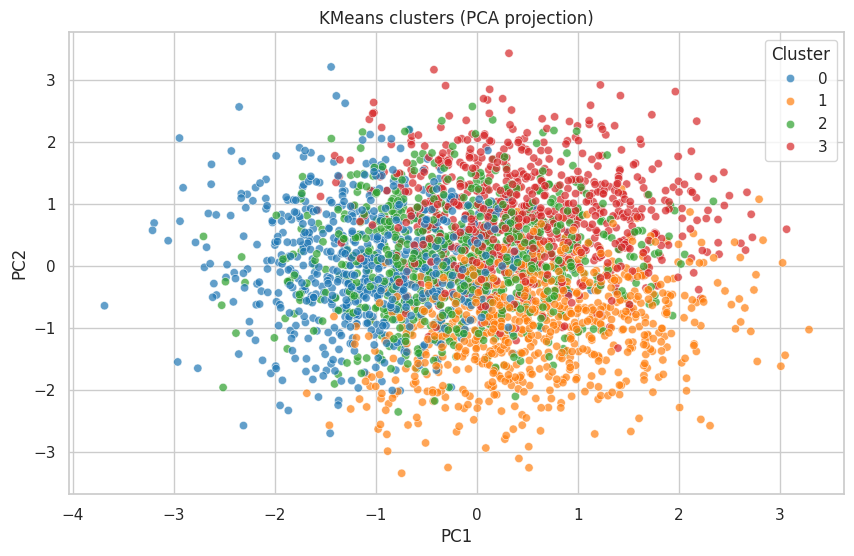

,count
Cluster,
1,783
3,763
2,735
0,719


In [30]:
cluster_features = ["AI_Exposure_Index","Tech_Growth_Factor"] + skill_cols
X_cluster = data[cluster_features].fillna(0)

# Standardize
scaler = StandardScaler()
Xc = scaler.fit_transform(X_cluster)

# KMeans with 4 clusters (example)
kmeans = KMeans(n_clusters=4, random_state=42)
data["Cluster"] = kmeans.fit_predict(Xc)

# Visualize clusters using PCA
pca = PCA(n_components=2, random_state=42)
pc = pca.fit_transform(Xc)
plt.figure(figsize=(10,6))
sns.scatterplot(x=pc[:,0], y=pc[:,1], hue=data["Cluster"], palette="tab10", alpha=0.7)
plt.title("KMeans clusters (PCA projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

data["Cluster"].value_counts()


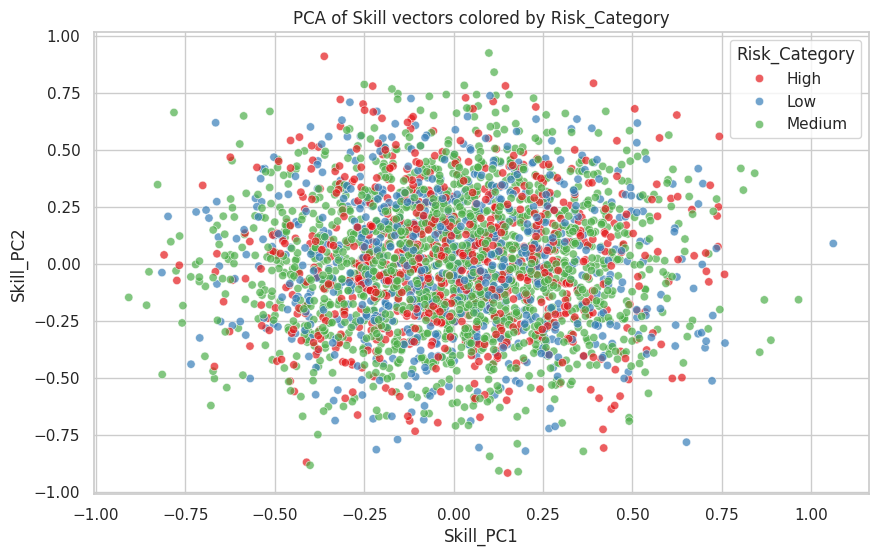

Explained variance ratio (skills PCA): [0.11047437 0.10669275]


In [31]:
# PCA on skill set to reduce to 2 components for visualization
skill_matrix = data[skill_cols].fillna(0)
pca_skills = PCA(n_components=2, random_state=42)
skills_pc = pca_skills.fit_transform(skill_matrix)

data["Skill_PC1"] = skills_pc[:,0]
data["Skill_PC2"] = skills_pc[:,1]

plt.figure(figsize=(10,6))
sns.scatterplot(x="Skill_PC1", y="Skill_PC2", hue="Risk_Category", data=data, palette="Set1", alpha=0.7)
plt.title("PCA of Skill vectors colored by Risk_Category")
plt.show()

print("Explained variance ratio (skills PCA):", pca_skills.explained_variance_ratio_)


In [32]:
# 1. Skill aggregate features
data["Skill_Mean"] = data[skill_cols].mean(axis=1)
data["Skill_Max"] = data[skill_cols].max(axis=1)
data["Skill_Count_High"] = (data[skill_cols] > 0.7).sum(axis=1)

# 2. Interaction features
data["AIexp_x_TechGrowth"] = data["AI_Exposure_Index"] * data["Tech_Growth_Factor"]

# 3. Experience buckets
data["Exp_Bucket"] = pd.cut(data["Years_Experience"], bins=[-1,2,5,10,20,40,100], labels=["0-2","3-5","6-10","11-20","21-40","40+"])

# 4. Salary normalization and log transform
data["Log_Avg_Salary"] = np.log1p(data["Average_Salary"])
data["Salary_per_Exp"] = data["Average_Salary"] / (data["Years_Experience"] + 1)

# 5. Recompute feature sets for modeling if needed
engineered_features = ["Skill_Mean","Skill_Max","Skill_Count_High","AIexp_x_TechGrowth","Log_Avg_Salary","Salary_per_Exp"]


In [33]:
# Top 5 insights (automatically derived)
insights = []

# 1. Jobs with highest automation probability
top_auto = data.sort_values("Automation_Probability_2030", ascending=False).head(10)[["Job_Title","Average_Salary","Automation_Probability_2030","Risk_Category"]]
insights.append(("Top automatable jobs (by Automation_Probability_2030)", top_auto))

# 2. Jobs with highest average salary
top_salary = data.sort_values("Average_Salary", ascending=False).head(10)[["Job_Title","Average_Salary","Automation_Probability_2030","Risk_Category"]]
insights.append(("Top paid jobs", top_salary))

# 3. Correlation highlight
corr_with_auto = corr["Automation_Probability_2030"].sort_values(ascending=False)
insights.append(("Top correlations with Automation_Probability_2030", corr_with_auto.head(10)))

# 4. Skill signals
top_skill_features = importances.head(10) if 'importances' in globals() else None
insights.append(("Top predictive features for automation (from regressor)", top_skill_features))

# 5. Clusters summary
cluster_counts = data["Cluster"].value_counts()
insights.append(("Cluster counts", cluster_counts))

# Print insights
for title, obj in insights:
    print("=== ", title, " ===")
    display(obj)
    print("\n")

# Recommendations (text)
print("Recommendations:")
print("- Prioritize reskilling for roles in the top automatable list; focus on skills with high predictive importance.")
print("- For organizations: combine Tech_Growth_Factor and AI_Exposure_Index when planning workforce transitions.")
print("- For individuals: increase skill diversity (higher Skill_Mean and Skill_Count_High) to reduce automation risk.")


===  Top automatable jobs (by Automation_Probability_2030)  ===


,Job_Title,Average_Salary,Automation_Probability_2030,Risk_Category
2261,Retail Worker,54287.0,0.95,High
2292,Retail Worker,105450.0,0.95,High
2121,Construction Worker,67788.0,0.95,High
2933,Customer Support,88880.0,0.95,High
2138,Truck Driver,129892.0,0.95,High
2376,Retail Worker,50242.0,0.95,High
87,Retail Worker,58602.0,0.95,High
1021,Security Guard,103251.0,0.95,High
1740,Truck Driver,116030.0,0.95,High
2856,Security Guard,33827.0,0.95,High




===  Top paid jobs  ===


,Job_Title,Average_Salary,Automation_Probability_2030,Risk_Category
150,Customer Support,149798.0,0.74,High
2245,Doctor,149756.0,0.07,Low
1730,Graphic Designer,149700.0,0.61,Medium
1467,Marketing Manager,149635.0,0.65,Medium
2514,Mechanic,149593.0,0.52,Medium
2580,Security Guard,149554.0,0.93,High
879,Lawyer,149528.0,0.64,Medium
2366,Mechanic,149511.0,0.43,Medium
975,Graphic Designer,149487.0,0.66,Medium
1827,Nurse,149401.0,0.30,Low




===  Top correlations with Automation_Probability_2030  ===


...



===  Top predictive features for automation (from regressor)  ===


,0
Average_Salary,0.084997
Skill_1,0.075109
Skill_4,0.075007
Skill_2,0.074941
Tech_Growth_Factor,0.071736
Skill_5,0.071636
Skill_3,0.070728
Skill_9,0.070384
AI_Exposure_Index,0.069957
Skill_6,0.069899




===  Cluster counts  ===


,count
Cluster,
1,783
3,763
2,735
0,719




Recommendations:
- Prioritize reskilling for roles in the top automatable list; focus on skills with high predictive importance.
- For organizations: combine Tech_Growth_Factor and AI_Exposure_Index when planning workforce transitions.
- For individuals: increase skill diversity (higher Skill_Mean and Skill_Count_High) to reduce automation risk.
